#  05 Business Model Development for AI-Based Products and Analysis of Ethical Challenges in Real-World AI Applications

Dataset: https://www.kaggle.com/datasets/rhuebner/human-resources-data-set?resource=download

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
df = pd.read_csv("hrdata.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [5]:
df.columns

Index(['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID',
       'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID',
       'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB',
       'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc',
       'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus',
       'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences'],
      dtype='object')

In [6]:
df['PerformanceScore'].unique()

array(['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP'], dtype=object)

In [7]:
le = LabelEncoder()
df['PerformanceScore'] = le.fit_transform(df['PerformanceScore'])

In [8]:
features = [
    'Salary',
    'EngagementSurvey',
    'EmpSatisfaction',
    'SpecialProjectsCount',
    'Absences',
    'DaysLateLast30'
]

X = df[features]
y = df['PerformanceScore']

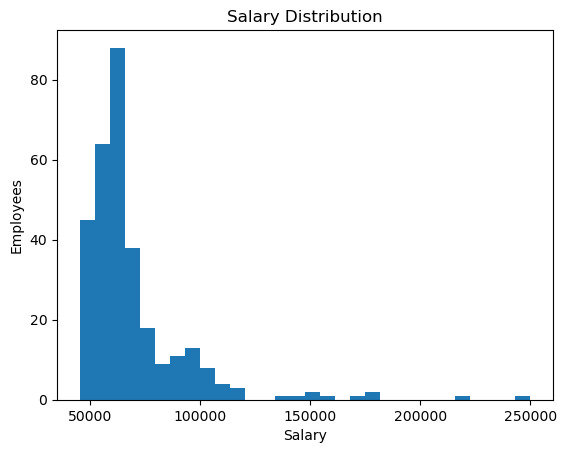

In [9]:
plt.hist(df['Salary'], bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Employees")
plt.show()

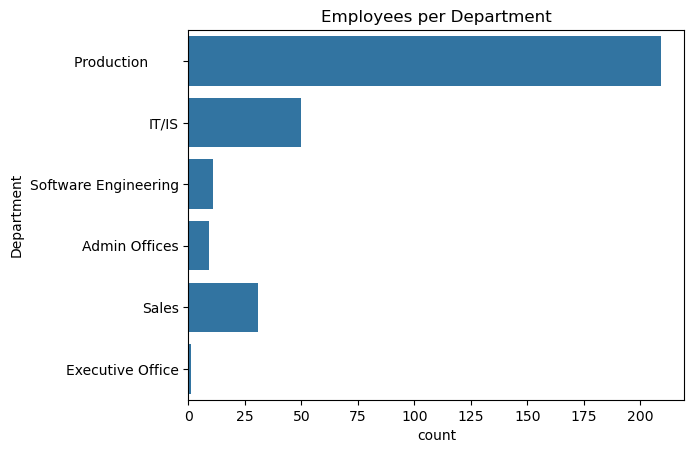

In [10]:
sns.countplot(y=df['Department'])
plt.title("Employees per Department")
plt.show()

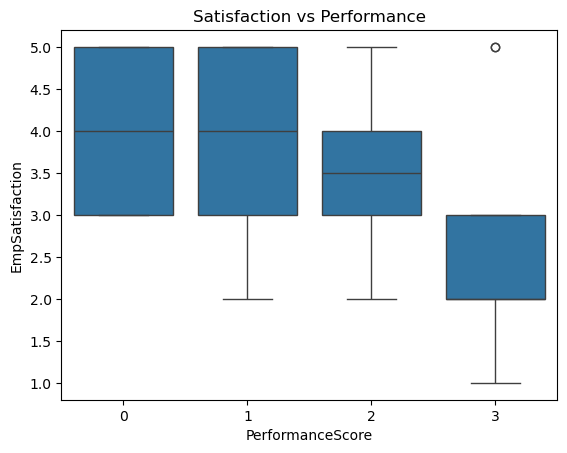

In [11]:
sns.boxplot(x=df['PerformanceScore'], y=df['EmpSatisfaction'])
plt.title("Satisfaction vs Performance")
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model using training data (learn patterns)
model.fit(X_train, y_train)

# Use the trained model to make predictions on test data
pred = model.predict(X_test)

# Calculate how many predictions are correct
accuracy = accuracy_score(y_test, pred)

# Print the accuracy result
print("Accuracy:", accuracy)

Accuracy: 0.873015873015873


C:\Users\kambl\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create Decision Tree model
dt = DecisionTreeClassifier()

# Train the model using training data
dt.fit(X_train, y_train)

# Make predictions on test data
pred = dt.predict(X_test)

# Check how many predictions are correct
accuracy = accuracy_score(y_test, pred)

# Print result
print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.7301587301587301


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=200).fit(X_train, y_train)
pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8888888888888888


In [25]:
salary = float(input("Enter Salary: "))
engagement = float(input("Enter Engagement Survey Score (1-5): "))
satisfaction = float(input("Enter Employee Satisfaction Score (1-5): "))
projects = int(input("Enter Special Projects Count: "))
absences = int(input("Enter Number of Absences: "))
late_days = int(input("Enter Days Late in Last 30 Days: "))

sample = [[salary, engagement, satisfaction, projects, absences, late_days]]
prediction = rf.predict(sample)
result = le.inverse_transform(prediction)
print("Predicted Performance:", result[0])

Enter Salary:  50000
Enter Engagement Survey Score (1-5):  4
Enter Employee Satisfaction Score (1-5):  3
Enter Special Projects Count:  2
Enter Number of Absences:  8
Enter Days Late in Last 30 Days:  12


Predicted Performance: Needs Improvement


C:\Users\kambl\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [26]:
salary = float(input("Enter Salary: "))
engagement = float(input("Enter Engagement Survey Score (1-5): "))
satisfaction = float(input("Enter Employee Satisfaction Score (1-5): "))
projects = int(input("Enter Special Projects Count: "))
absences = int(input("Enter Number of Absences: "))
late_days = int(input("Enter Days Late in Last 30 Days: "))

sample = [[salary, engagement, satisfaction, projects, absences, late_days]]
prediction = rf.predict(sample)
result = le.inverse_transform(prediction)
print("Predicted Performance:", result[0])

Enter Salary:  80000
Enter Engagement Survey Score (1-5):  4
Enter Employee Satisfaction Score (1-5):  4
Enter Special Projects Count:  6
Enter Number of Absences:  2
Enter Days Late in Last 30 Days:  1


Predicted Performance: Fully Meets


C:\Users\kambl\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
